In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Data Analysis

In [4]:
heart_data = pd.read_csv('heart_disease_data.csv')

In [5]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
heart_data.shape

(303, 14)

In [8]:
heart_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [9]:
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



===== DATASET =====
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

===== INFORMASI DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null  

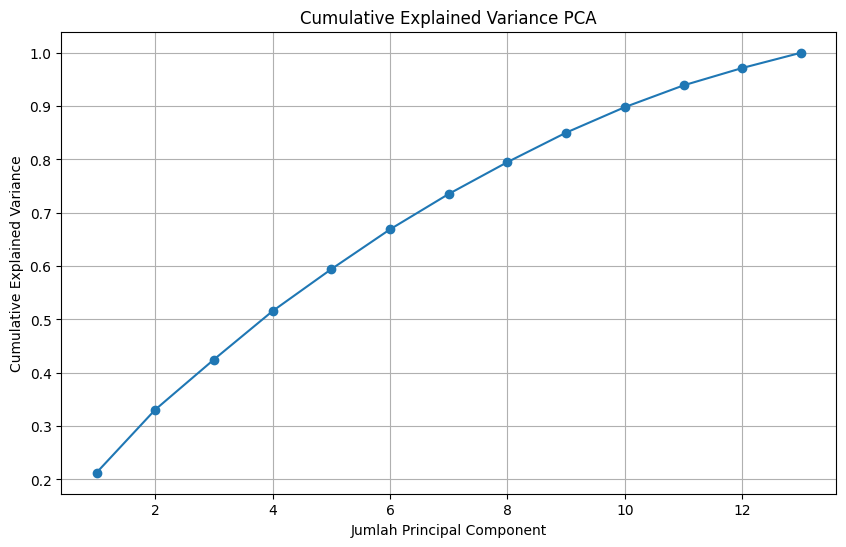


===== INFORMASI PCA =====
Jumlah fitur awal : 13
Jumlah principal component : 12
Bentuk data PCA : (303, 12)

===== DATA HASIL PCA =====
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.624111  2.321270  2.474673 -2.676239 -0.375253 -1.713567 -0.120352   
1 -0.455988 -0.957351  1.139595 -2.426838 -2.273767  0.787861 -0.081513   
2 -1.828805  0.042885 -0.452229 -0.406415 -0.867802 -0.767551 -0.104852   
3 -1.716006 -0.495337  0.030631  0.112162  0.235598  0.502665 -0.142754   
4 -0.371356  0.301156 -2.841069  0.809042 -0.011389  0.085495  1.415596   

        PC8       PC9      PC10      PC11      PC12  target  
0 -0.736557 -0.638940  0.932651 -0.558115  0.404075       1  
1 -1.535384  1.241824  1.165681 -0.492133  0.232260       1  
2  0.063523  1.293202 -1.147066  0.363725  0.177977       1  
3  0.177462 -0.152965  0.706572 -0.700291  1.073581       1  
4 -0.607134 -0.186315  0.907423  0.414451  0.884467       1  

===== EIGENVALUE =====
   Principal_Co

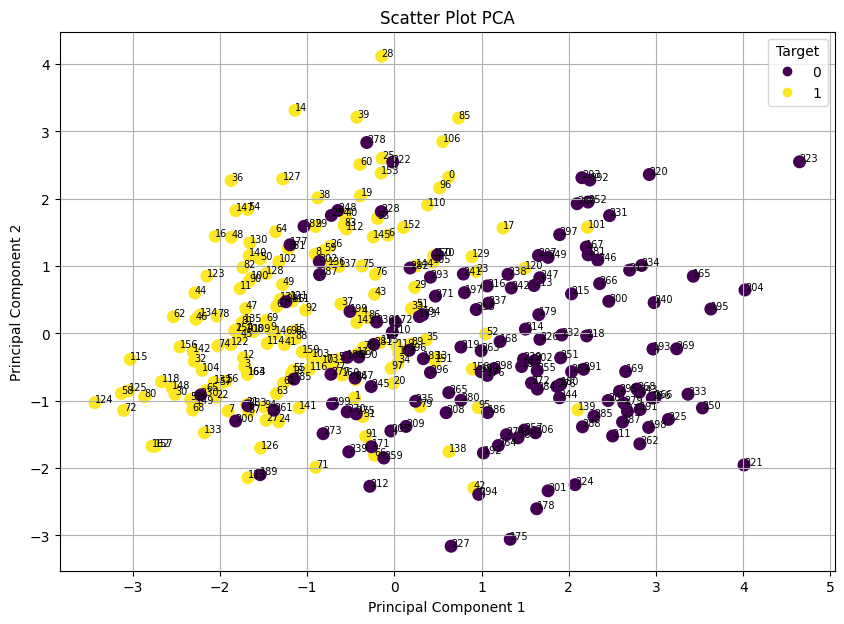

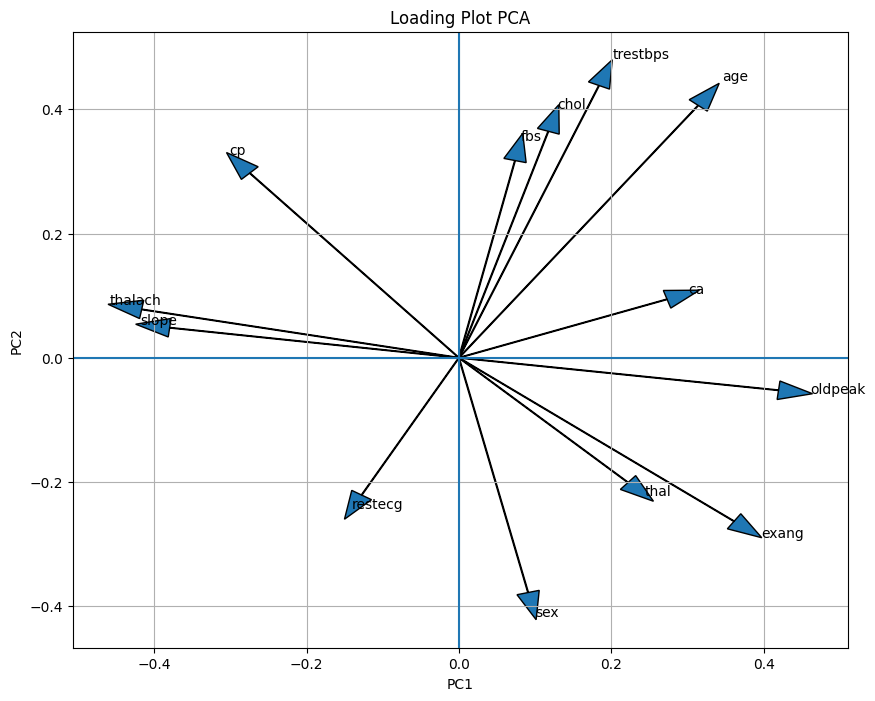


===== INTERPRETASI =====

PCA berhasil mereduksi dimensi data
dari 13 fitur menjadi
12 principal component.


Principal Component pertama
menjelaskan variasi terbesar data.

Principal Component kedua
menjelaskan variasi terbesar berikutnya
yang bersifat orthogonal terhadap PC1.


Hasil PCA berhasil disimpan
Nama file : hasil_pca_heart.csv

Program selesai dijalankan


In [24]:
# ============================================================
# PRINCIPAL COMPONENT ANALYSIS (PCA)
# DATASET : HEART DISEASE
# + TABEL ANALISIS
# + VISUALISASI SCATTER
# + LOADING PLOT
# ============================================================

# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# MEMBACA DATASET
# ============================================================

heart_data = pd.read_csv(
    'heart_disease_data.csv'
)

# ============================================================
# MENAMPILKAN DATASET
# ============================================================

print("\n===== DATASET =====")

print(
    heart_data.head()
)

# ============================================================
# INFORMASI DATASET
# ============================================================

print("\n===== INFORMASI DATASET =====")

print(
    heart_data.info()
)

# ============================================================
# CEK MISSING VALUE
# ============================================================

print("\n===== MISSING VALUE =====")

print(
    heart_data.isnull().sum()
)

# ============================================================
# MEMISAHKAN FITUR DAN TARGET
# ============================================================

# ============================================================
# TARGET TIDAK DIGUNAKAN DALAM PCA
# TARGET HANYA UNTUK VISUALISASI
# ============================================================

X = heart_data.drop(
    columns=['target']
)

y = heart_data['target']

# ============================================================
# MENAMPILKAN FITUR
# ============================================================

print("\n===== FITUR =====")

print(
    X.head()
)

# ============================================================
# NORMALISASI DATA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData berhasil dinormalisasi")

# ============================================================
# PCA AWAL
# ============================================================

pca = PCA()

X_pca = pca.fit_transform(
    X_scaled
)

# ============================================================
# EXPLAINED VARIANCE
# ============================================================

explained_variance = (
    pca.explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    explained_variance
)

# ============================================================
# TABEL EXPLAINED VARIANCE
# ============================================================

tabel_variance = pd.DataFrame({

    'Principal_Component' : [

        f'PC{i+1}'

        for i in range(
            len(explained_variance)
        )

    ],

    'Explained_Variance' :
        explained_variance,

    'Cumulative_Variance' :
        cumulative_variance

})

print("\n===== TABEL EXPLAINED VARIANCE =====")

print(
    tabel_variance
)

# ============================================================
# VISUALISASI EXPLAINED VARIANCE
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(

    range(
        1,
        len(explained_variance)+1
    ),

    cumulative_variance,

    marker='o'

)

plt.xlabel(
    'Jumlah Principal Component'
)

plt.ylabel(
    'Cumulative Explained Variance'
)

plt.title(
    'Cumulative Explained Variance PCA'
)

plt.grid(True)

plt.show()

# ============================================================
# PCA FINAL
# MEMPERTAHANKAN 95% INFORMASI
# ============================================================

pca_final = PCA(
    n_components=0.95
)

X_pca_final = pca_final.fit_transform(
    X_scaled
)

# ============================================================
# JUMLAH KOMPONEN
# ============================================================

print("\n===== INFORMASI PCA =====")

print(
    "Jumlah fitur awal :",
    X.shape[1]
)

print(
    "Jumlah principal component :",
    pca_final.n_components_
)

print(
    "Bentuk data PCA :",
    X_pca_final.shape
)

# ============================================================
# MEMBUAT NAMA PRINCIPAL COMPONENT
# ============================================================

nama_pc = []

for i in range(
    pca_final.n_components_
):

    nama_pc.append(
        f'PC{i+1}'
    )

# ============================================================
# MEMBUAT DATAFRAME PCA
# ============================================================

DF_PCA = pd.DataFrame(

    X_pca_final,

    columns=nama_pc

)

# ============================================================
# MENAMBAHKAN TARGET
# HANYA UNTUK VISUALISASI
# ============================================================

DF_PCA['target'] = y.values

# ============================================================
# MENAMPILKAN DATA PCA
# ============================================================

print("\n===== DATA HASIL PCA =====")

print(
    DF_PCA.head()
)

# ============================================================
# EIGENVALUE
# ============================================================

eigenvalue = pd.DataFrame({

    'Principal_Component' : [

        f'PC{i+1}'

        for i in range(
            len(
                pca.explained_variance_
            )
        )

    ],

    'Eigenvalue' :
        pca.explained_variance_

})

print("\n===== EIGENVALUE =====")

print(
    eigenvalue
)

# ============================================================
# LOADING FACTOR
# ============================================================

loading = pd.DataFrame(

    pca.components_.T,

    columns=[

        f'PC{i+1}'

        for i in range(
            len(pca.components_)
        )

    ],

    index=X.columns

)

print("\n===== LOADING FACTOR =====")

print(
    loading
)

# ============================================================
# VISUALISASI SCATTER PCA
# ============================================================

if pca_final.n_components_ >= 2:

    plt.figure(figsize=(10,7))

    scatter = plt.scatter(

        DF_PCA['PC1'],
        DF_PCA['PC2'],

        c=DF_PCA['target'],

        s=70

    )

    # ========================================================
    # LABEL DATA
    # ========================================================

    for i in range(len(DF_PCA)):

        plt.text(

            DF_PCA['PC1'][i],
            DF_PCA['PC2'][i],

            str(i),

            fontsize=7

        )

    # ========================================================
    # LEGEND
    # ========================================================

    plt.legend(

        *scatter.legend_elements(),

        title="Target"

    )

    plt.xlabel(
        'Principal Component 1'
    )

    plt.ylabel(
        'Principal Component 2'
    )

    plt.title(
        'Scatter Plot PCA'
    )

    plt.grid(True)

    plt.show()

# ============================================================
# LOADING PLOT
# ============================================================

plt.figure(figsize=(10,8))

for i, feature in enumerate(X.columns):

    plt.arrow(

        0,
        0,

        loading.iloc[i,0],
        loading.iloc[i,1],

        head_width=0.03

    )

    plt.text(

        loading.iloc[i,0] * 1.1,
        loading.iloc[i,1] * 1.1,

        feature,

        fontsize=10

    )

plt.xlabel('PC1')

plt.ylabel('PC2')

plt.title(
    'Loading Plot PCA'
)

plt.grid(True)

plt.axhline(y=0)

plt.axvline(x=0)

plt.show()

# ============================================================
# INTERPRETASI
# ============================================================

print("\n===== INTERPRETASI =====")

print(

    f"""
PCA berhasil mereduksi dimensi data
dari {X.shape[1]} fitur menjadi
{pca_final.n_components_} principal component.
"""

)

print(

    """
Principal Component pertama
menjelaskan variasi terbesar data.

Principal Component kedua
menjelaskan variasi terbesar berikutnya
yang bersifat orthogonal terhadap PC1.
"""

)

# ============================================================
# SIMPAN HASIL PCA
# ============================================================

DF_PCA.to_csv(

    'hasil_pca_heart.csv',

    index=False

)

print(
    "\nHasil PCA berhasil disimpan"
)

print(
    "Nama file : hasil_pca_heart.csv"
)

# ============================================================
# SELESAI
# ============================================================

print(
    "\nProgram selesai dijalankan"
)